# TPMT / NUDT15 Star Allele Analysis

Pharmacogenomic analysis of TPMT and NUDT15 star-allele calls in paediatric ALL (T-ALL and BCP-ALL cohorts), linking genotype/phenotype to sequencing confidence, clinical outcome, genetic subtype, and RNA-seq expression.

Patient-level tables are written to CSV rather than displayed inline; only aggregated/group-level summaries are shown in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import requests
import time

sns.set_style("whitegrid")

## 1. Load and annotate data

In [2]:
df = pd.read_csv('~/Downloads/combined_summary.csv')
print(f"Total rows: {len(df)}")
print(f"Patients: {df['patient_id'].nunique()}")

Total rows: 92
Patients: 46


Add sequencing type (WGS vs WES), mean coverage depth, and a confidence tier per call. NUDT15 calls from WES have effectively no coverage and TPMT WES calls are low-confidence; only WGS calls are treated as reliable downstream.

In [3]:
# Sequencing type: all T-ALL plus P0067 and P0116 (BCP-ALL) were WGS; remaining BCP-ALL samples were WES
wgs_patients = set(df[df['cohort'] == 'T-ALL']['patient_id']) | {'P0067', 'P0116'}
df['sequencing_type'] = df['patient_id'].apply(lambda x: 'WGS' if x in wgs_patients else 'WES')

# Real WGS depths from the Sonic depth check
wgs_depth = pd.read_csv('~/Downloads/wgs_depth_check.tsv', sep='\t', header=None,
                         names=['patient_id', 'gene', 'mean_depth'])

# WES depths from the earlier depth check
wes_depth_data = {
    ('P0078', 'TPMT'): 6.00891, ('P0078', 'NUDT15'): 0.177494,
    ('P0109', 'TPMT'): 6.85114, ('P0109', 'NUDT15'): 0.267724,
    ('P0179', 'TPMT'): 4.50823, ('P0179', 'NUDT15'): 0.677911,
    ('P0178', 'TPMT'): 4.13251, ('P0178', 'NUDT15'): 0.263691,
    ('P0082', 'TPMT'): 7.11284, ('P0082', 'NUDT15'): 0.335855,
    ('P0182', 'TPMT'): 4.29266, ('P0182', 'NUDT15'): 0.375021,
    ('P0183', 'TPMT'): 4.92356, ('P0183', 'NUDT15'): 0.300223,
    ('P0180', 'TPMT'): 4.23444, ('P0180', 'NUDT15'): 0.186327,
    ('P0117', 'TPMT'): 7.67139, ('P0117', 'NUDT15'): 0.146828,
    ('P0136', 'TPMT'): 5.30666, ('P0136', 'NUDT15'): 0.362788,
    ('P0135', 'TPMT'): 4.07324, ('P0135', 'NUDT15'): 0.704943,
}

depth_lookup = {(row['patient_id'], row['gene']): row['mean_depth'] for _, row in wgs_depth.iterrows()}
depth_lookup.update(wes_depth_data)
df['mean_depth'] = df.apply(lambda r: depth_lookup.get((r['patient_id'], r['gene'])), axis=1)

def reliability(row):
    if row['sequencing_type'] == 'WGS':
        return 'Reliable (WGS)'
    elif row['gene'] == 'NUDT15':
        return 'Unreliable (WES, ~0x depth)'
    else:
        return 'Low-confidence (WES, <10x depth)'

df['confidence'] = df.apply(reliability, axis=1)

# Save the annotated full dataset for transparency / methods appendix
df.to_csv('~/Downloads/combined_summary_annotated.csv', index=False)
reliable = df[df['confidence'] == 'Reliable (WGS)'].copy()

In [4]:
# Confidence tier summary, per gene
df.groupby(['gene', 'confidence']).size().unstack(fill_value=0)

confidence,"Low-confidence (WES, <10x depth)",Reliable (WGS),"Unreliable (WES, ~0x depth)"
gene,,,
NUDT15,0,35,11
TPMT,11,35,0


In [5]:
# Methods-section table: coverage depth summary by sequencing type and gene
depth_summary = df.groupby(['sequencing_type', 'gene'])['mean_depth'].agg(['mean', 'min', 'max', 'count']).round(2)
depth_summary

mean    min    max  count
sequencing_type gene                              
WES             NUDT15   0.35   0.15   0.70     11
                TPMT     5.37   4.07   7.67     11
WGS             NUDT15  37.52  22.04  67.32     35
                TPMT    36.77  22.01  66.17     35

## 2. Phenotype distribution overview

In [6]:
# Phenotype counts by gene (all calls)
df.groupby(['gene', 'phenotype']).size().unstack(fill_value=0)

phenotype,Indeterminate,Intermediate Metabolizer,Normal Metabolizer,Poor Metabolizer
gene,,,,
NUDT15,5,2,37,2
TPMT,10,3,33,0


#### Phenotype distribution by gene

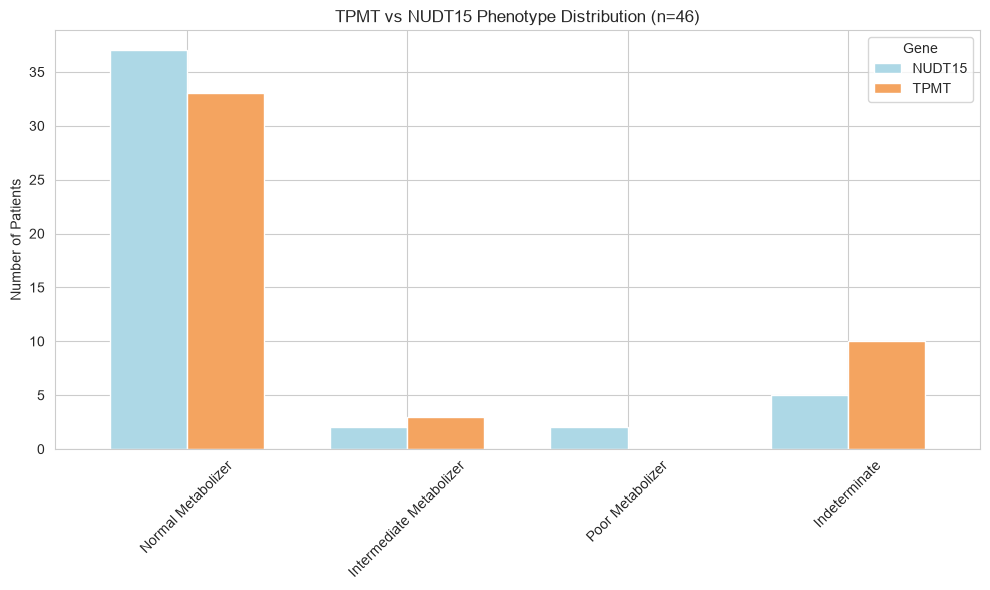

In [7]:
counts = df.groupby(['phenotype', 'gene']).size().unstack(fill_value=0)
phenotype_order = ['Normal Metabolizer', 'Intermediate Metabolizer', 'Poor Metabolizer', 'Indeterminate']
counts = counts.reindex(phenotype_order).fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
counts.plot(kind='bar', ax=ax, color=['lightblue', 'sandybrown'], width=0.7)
ax.set_title(f'TPMT vs NUDT15 Phenotype Distribution (n={df["patient_id"].nunique()})')
ax.set_xlabel('')
ax.set_ylabel('Number of Patients')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Gene')

plt.tight_layout()
plt.savefig('phenotype_distribution_combined.png', dpi=150, bbox_inches='tight')
plt.show()

#### Phenotype distribution split by cohort (T-ALL vs BCP-ALL)

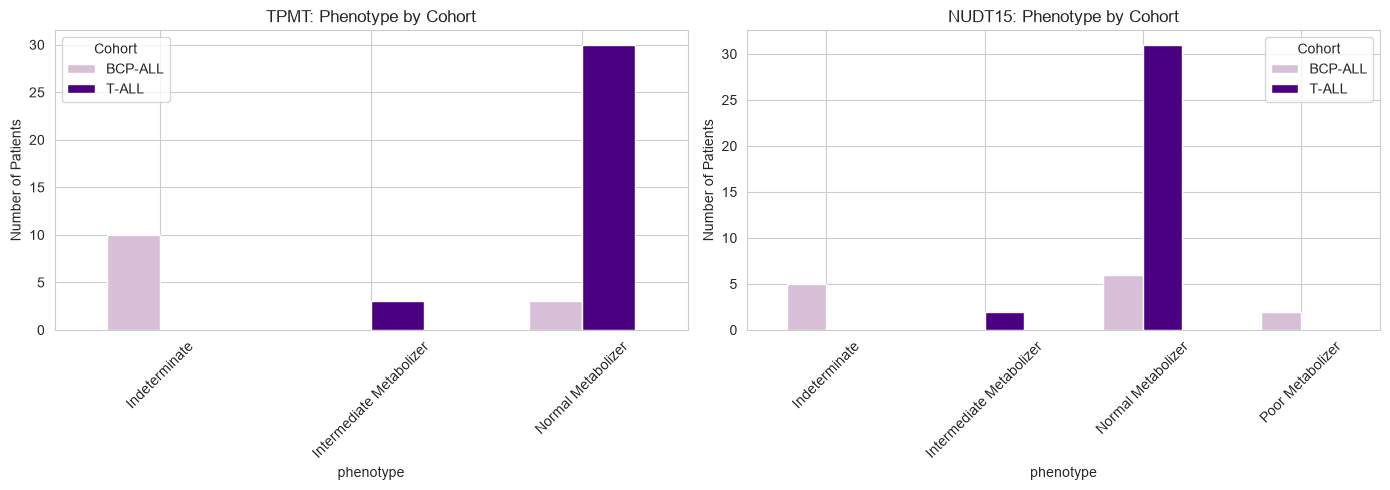

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, gene in zip(axes, ['TPMT', 'NUDT15']):
    subset = df[df['gene'] == gene]
    cross = pd.crosstab(subset['phenotype'], subset['cohort'])
    cross.plot(kind='bar', ax=ax, color=['thistle', 'indigo'])
    ax.set_title(f'{gene}: Phenotype by Cohort')
    ax.set_ylabel('Number of Patients')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Cohort')

plt.tight_layout()
plt.savefig('phenotype_by_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

#### Phenotype distribution using only reliable (WGS) calls

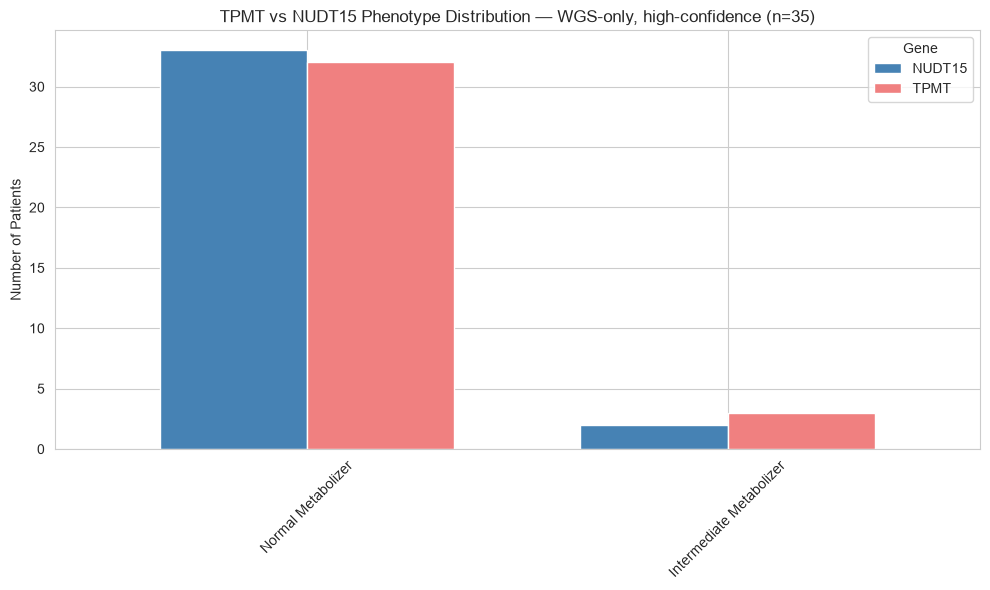

In [9]:
counts = reliable.groupby(['phenotype', 'gene']).size().unstack(fill_value=0)
counts = counts.reindex(phenotype_order).dropna(how='all').fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'lightcoral'], width=0.7)
ax.set_title(f'TPMT vs NUDT15 Phenotype Distribution — WGS-only, high-confidence (n={reliable["patient_id"].nunique()})')
ax.set_xlabel('')
ax.set_ylabel('Number of Patients')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Gene')

plt.tight_layout()
plt.savefig('phenotype_distribution_reliable_only.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Clinically actionable and indeterminate calls

In [10]:
actionable = df[df['phenotype'].isin(['Poor Metabolizer', 'Intermediate Metabolizer'])].copy()
actionable = actionable.sort_values(['gene', 'phenotype'])
actionable[['patient_id', 'cohort', 'gene', 'genotype', 'phenotype']].to_csv('~/Downloads/actionable_calls.csv', index=False)
print(f"{len(actionable)} clinically actionable calls saved to actionable_calls.csv")

7 clinically actionable calls saved to actionable_calls.csv


In [11]:
indeterminate = df[df['phenotype'] == 'Indeterminate'].copy()
indeterminate[['patient_id', 'cohort', 'gene', 'genotype']].sort_values(['gene', 'genotype']).to_csv('~/Downloads/indeterminate_calls.csv', index=False)
print(f"{len(indeterminate)} indeterminate calls saved to indeterminate_calls.csv (need manual CPIC cross-reference)")

15 indeterminate calls saved to indeterminate_calls.csv (need manual CPIC cross-reference)


## 4. CPIC dosing guidance

In [12]:
# CPIC TPMT/NUDT15 phenotype-based thiopurine dosing guidance (Relling et al.)
cpic_guidance = {
    'Normal Metabolizer': 'Start standard dose (e.g., azathioprine 2-3 mg/kg/day); no adjustment required',
    'Intermediate Metabolizer': 'Start at 30-70% of standard dose; titrate based on toxicity/efficacy and myelosuppression monitoring',
    'Poor Metabolizer': 'Start at 10% of standard dose, given thrice weekly instead of daily, or consider alternative agent; high risk of severe/life-threatening myelosuppression at normal doses',
    'Indeterminate': 'Insufficient evidence for confident phenotype assignment; recommend confirmatory testing (e.g., repeat with higher-depth sequencing or targeted genotyping) before dose adjustment'
}

df['cpic_guidance'] = df['phenotype'].map(cpic_guidance)
reliable = df[df['confidence'] == 'Reliable (WGS)']

guidance_needed = reliable[reliable['phenotype'] != 'Normal Metabolizer'][
    ['patient_id', 'cohort', 'gene', 'genotype', 'phenotype', 'cpic_guidance']
]
guidance_needed.to_csv('~/Downloads/actionable_calls_with_guidance.csv', index=False)
print(f"{len(guidance_needed)} reliable calls with non-standard dosing guidance saved to actionable_calls_with_guidance.csv")

5 reliable calls with non-standard dosing guidance saved to actionable_calls_with_guidance.csv


## 5. Population allele frequency validation

In [13]:
# Observed frequencies (WGS-reliable, n=35) vs published CPIC/PharmVar population frequencies
tpmt_reliable = reliable[reliable['gene'] == 'TPMT']
nudt15_reliable = reliable[reliable['gene'] == 'NUDT15']

tpmt_3a_carriers = tpmt_reliable[tpmt_reliable['genotype'].str.contains('3A', na=False)]
nudt15_3_carriers = nudt15_reliable[nudt15_reliable['genotype'].str.contains(r'\*3(?!\d)', na=False, regex=True)]

print(f"TPMT*3A carriers: {len(tpmt_3a_carriers)}/{len(tpmt_reliable)} = {100*len(tpmt_3a_carriers)/len(tpmt_reliable):.1f}%")
print("(Literature: TPMT*1/*3A diplotype ~7.1% in European populations)")
print()
print(f"NUDT15*3 carriers: {len(nudt15_3_carriers)}/{len(nudt15_reliable)} = {100*len(nudt15_3_carriers)/len(nudt15_reliable):.1f}%")
print("(Literature: NUDT15*3 <1% in European populations, ~6-6.7% in Asian populations)")

TPMT*3A carriers: 3/35 = 8.6%
(Literature: TPMT*1/*3A diplotype ~7.1% in European populations)

NUDT15*3 carriers: 2/35 = 5.7%
(Literature: NUDT15*3 <1% in European populations, ~6-6.7% in Asian populations)


**TPMT\*3A: strong validation.** The observed frequency closely matches the European literature value — independent evidence that the pipeline (download → variant calling → star allele assignment) is working correctly, since it reproduces a known population parameter.

**NUDT15\*3: unexpectedly high — worth flagging.** The observed frequency is well above the European estimate but consistent with Asian population frequencies. This could reflect small-sample noise, non-European ancestry in the cohort, or a genotyping artifact.

In [14]:
# Sanity check: is the elevated NUDT15*3 frequency explained by low depth in those carriers?
nudt15_3_carriers['mean_depth'].describe()[['mean', 'min', 'max']]

mean    30.58855
min     30.03820
max     31.13890
Name: mean_depth, dtype: float64

Depth for the NUDT15\*3 carriers is in line with the rest of the reliable WGS cohort (~30x), so this is not a technical artifact. The most likely explanation is cohort ancestry — UKALL2003/2011 recruited broadly across the UK and Ireland, which includes real ethnic diversity.

## 6. Outcome analyses

### 6.1 T-ALL: TPMT genotype vs outcome

In [15]:
tall_outcomes = pd.read_csv('~/Downloads/tall_outcomes.csv')
tall_merged = reliable[reliable['cohort'] == 'T-ALL'].merge(
    tall_outcomes[['patient_id', 'outcome']], on='patient_id', how='left'
)

tpmt_tall = tall_merged[tall_merged['gene'] == 'TPMT']
ct_tpmt = pd.crosstab(tpmt_tall['phenotype'], tpmt_tall['outcome'])
print(ct_tpmt)

print("\nRelapse rate, Normal Metabolizer:",
      (tpmt_tall[tpmt_tall['phenotype']=='Normal Metabolizer']['outcome']=='Relapse').mean())
print("Relapse rate, Intermediate Metabolizer:",
      (tpmt_tall[tpmt_tall['phenotype']=='Intermediate Metabolizer']['outcome']=='Relapse').mean())

outcome                   CCR  Relapse  TRM
phenotype                                  
Intermediate Metabolizer    2        0    1
Normal Metabolizer         14       12    4

Relapse rate, Normal Metabolizer: 0.4
Relapse rate, Intermediate Metabolizer: 0.0


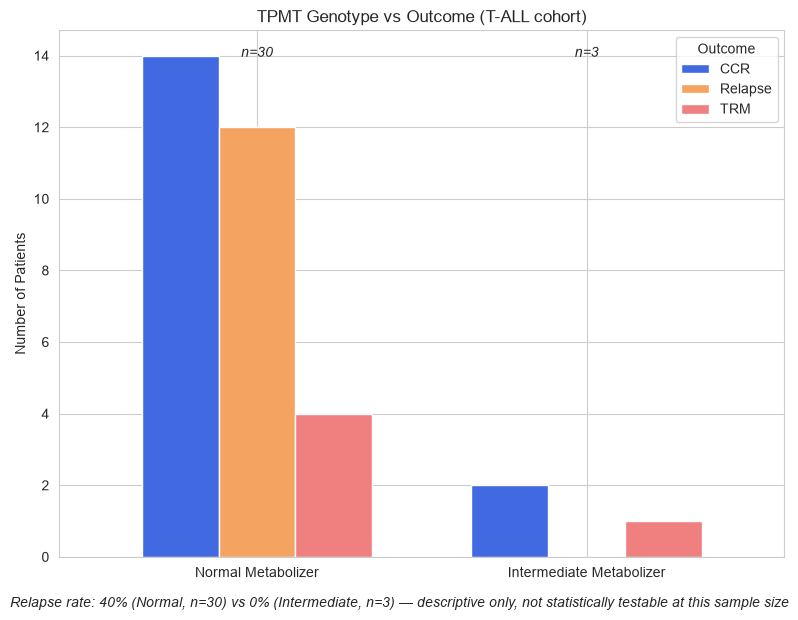

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

order = ['Normal Metabolizer', 'Intermediate Metabolizer']
ct_plot = ct_tpmt.reindex(order).fillna(0)
ct_plot.plot(kind='bar', ax=ax, color=['royalblue', 'sandybrown', 'lightcoral'], width=0.7)

ax.set_title('TPMT Genotype vs Outcome (T-ALL cohort)')
ax.set_xlabel('')
ax.set_ylabel('Number of Patients')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Outcome')

n_normal = ct_plot.loc['Normal Metabolizer'].sum()
n_intermediate = ct_plot.loc['Intermediate Metabolizer'].sum()
ax.text(0, ax.get_ylim()[1]*0.95, f'n={int(n_normal)}', ha='center', fontsize=10, style='italic')
ax.text(1, ax.get_ylim()[1]*0.95, f'n={int(n_intermediate)}', ha='center', fontsize=10, style='italic')

plt.figtext(0.5, -0.02,
            'Relapse rate: 40% (Normal, n=30) vs 0% (Intermediate, n=3) — descriptive only, not statistically testable at this sample size',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('tpmt_outcome_relapse_rates.png', dpi=150, bbox_inches='tight')
plt.show()

Relapse rate is 40% (Normal Metabolizer) vs 0% (Intermediate Metabolizer). Only 3 patients in the intermediate group — a descriptive difference, not a statistically testable one at this sample size.

### 6.2 T-ALL: NUDT15 genotype vs outcome

In [17]:
nudt15_tall = tall_merged[tall_merged['gene'] == 'NUDT15']
ct_nudt15 = pd.crosstab(nudt15_tall['phenotype'], nudt15_tall['outcome'])
print(ct_nudt15)

outcome                   CCR  Relapse  TRM
phenotype                                  
Intermediate Metabolizer    2        0    0
Normal Metabolizer         14       12    5


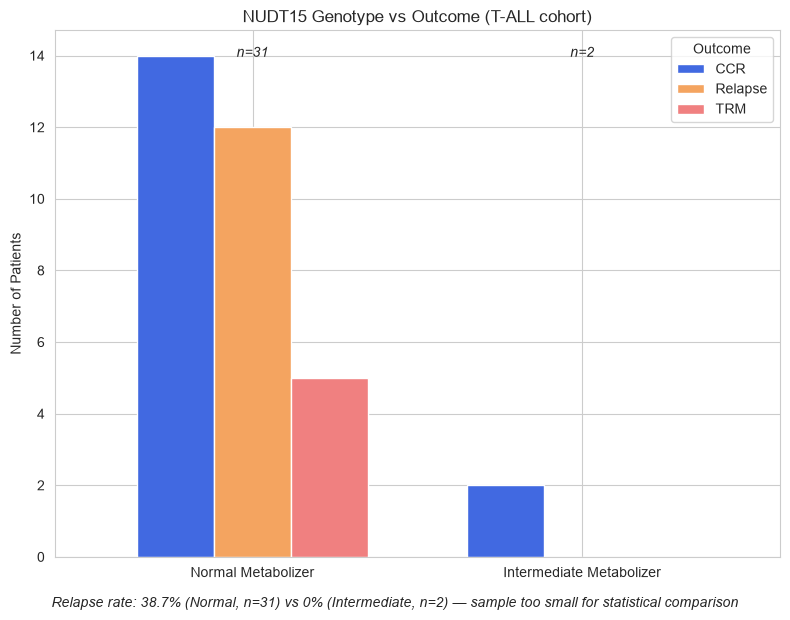

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

ct_plot = ct_nudt15.reindex(order).fillna(0)
ct_plot.plot(kind='bar', ax=ax, color=['royalblue', 'sandybrown', 'lightcoral'], width=0.7)

ax.set_title('NUDT15 Genotype vs Outcome (T-ALL cohort)')
ax.set_xlabel('')
ax.set_ylabel('Number of Patients')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Outcome')

n_normal = ct_plot.loc['Normal Metabolizer'].sum()
n_intermediate = ct_plot.loc['Intermediate Metabolizer'].sum()
ax.text(0, ax.get_ylim()[1]*0.95, f'n={int(n_normal)}', ha='center', fontsize=10, style='italic')
ax.text(1, ax.get_ylim()[1]*0.95, f'n={int(n_intermediate)}', ha='center', fontsize=10, style='italic')

plt.figtext(0.5, -0.02,
            'Relapse rate: 38.7% (Normal, n=31) vs 0% (Intermediate, n=2) — sample too small for statistical comparison',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('nudt15_outcome_relapse_rates.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 BCP-ALL: genotype vs remission time and blast %

In [19]:
# All BCP-ALL genotype calls used here (not just WGS-reliable), confidence tier retained for interpretation
bcpall_clinical = pd.read_csv('~/Downloads/bcpall_clinical.csv')
bcpall_all = df[df['cohort'] == 'BCP-ALL'].merge(
    bcpall_clinical[['patient_id', 'remission_time_years', 'blast_pct_diagnosis', 'blast_pct_relapse']],
    on='patient_id', how='left'
)

tpmt_bcp = bcpall_all[bcpall_all['gene'] == 'TPMT'][
    ['patient_id', 'genotype', 'phenotype', 'confidence', 'remission_time_years', 'blast_pct_diagnosis', 'blast_pct_relapse']
].sort_values('phenotype')
tpmt_bcp.to_csv('~/Downloads/bcpall_tpmt_clinical.csv', index=False)

tpmt_bcp.groupby('phenotype')['remission_time_years'].agg(['mean', 'std', 'count'])

,mean,std,count
phenotype,,,
Indeterminate,1.122740,0.43519,10
Normal Metabolizer,0.726027,0.22330,3


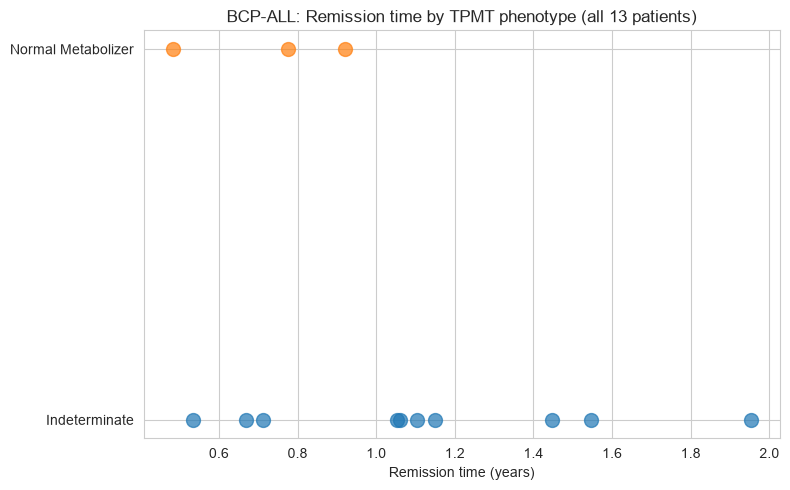

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
for phenotype, group in tpmt_bcp.groupby('phenotype'):
    ax.scatter(group['remission_time_years'], [phenotype]*len(group), s=100, alpha=0.7)
ax.set_xlabel('Remission time (years)')
ax.set_title('BCP-ALL: Remission time by TPMT phenotype (all 13 patients)')
plt.tight_layout()
plt.savefig('bcpall_remission_by_tpmt.png', dpi=150, bbox_inches='tight')
plt.show()

All 10 "Indeterminate" points are flagged low-confidence WES samples, and all 3 "Normal Metabolizer" points are exactly the 3 highest-confidence/WGS-adjacent samples. Phenotype and confidence tier are almost perfectly confounded in this cohort (low confidence → unusual genotype call; high confidence → clean \*1/\*1 call), so this plot is effectively showing sequencing confidence tier vs remission time rather than a genuine genotype effect. Any apparent pattern is likely noise from unreliable genotyping, not real biological signal.

### 6.4 T-ALL: genetic subtype vs phenotype

In [21]:
subtype_merged = reliable[reliable['cohort'] == 'T-ALL'].merge(
    tall_outcomes[['patient_id', 'final_group', 'ettp_status']], on='patient_id', how='left'
)

tpmt_subtype = subtype_merged[subtype_merged['gene'] == 'TPMT']
nudt15_subtype = subtype_merged[subtype_merged['gene'] == 'NUDT15']

print("=== TPMT phenotype by genetic subtype ===")
print(pd.crosstab(tpmt_subtype['phenotype'], tpmt_subtype['final_group']))

print("\n=== NUDT15 phenotype by genetic subtype ===")
print(pd.crosstab(nudt15_subtype['phenotype'], nudt15_subtype['final_group']))

=== TPMT phenotype by genetic subtype ===
final_group               HOX  LMO2_LYL1  Other  TAL1  TLX3
phenotype                                                  
Intermediate Metabolizer    2          0      0     0     1
Normal Metabolizer         14          2      2     6     6

=== NUDT15 phenotype by genetic subtype ===
final_group               HOX  LMO2_LYL1  Other  TAL1  TLX3
phenotype                                                  
Intermediate Metabolizer    2          0      0     0     0
Normal Metabolizer         14          2      2     6     7


HOXA accounts for 2/3 TPMT Intermediate Metaboliser cases and both NUDT15 Intermediate cases. In the source T-ALL cohort paper, HOXA was the most common and worst-prognosis subtype in the induction-failure group (~42% of induction-failure cases vs ~13% in responsive T-ALL).

All pharmacogene-variant carriers in this cohort happen to fall in the HOXA subtype. This could reflect base rates (HOXA is the largest single subgroup, 20/48 patients) or a genuinely interesting co-occurrence worth flagging — checked below.

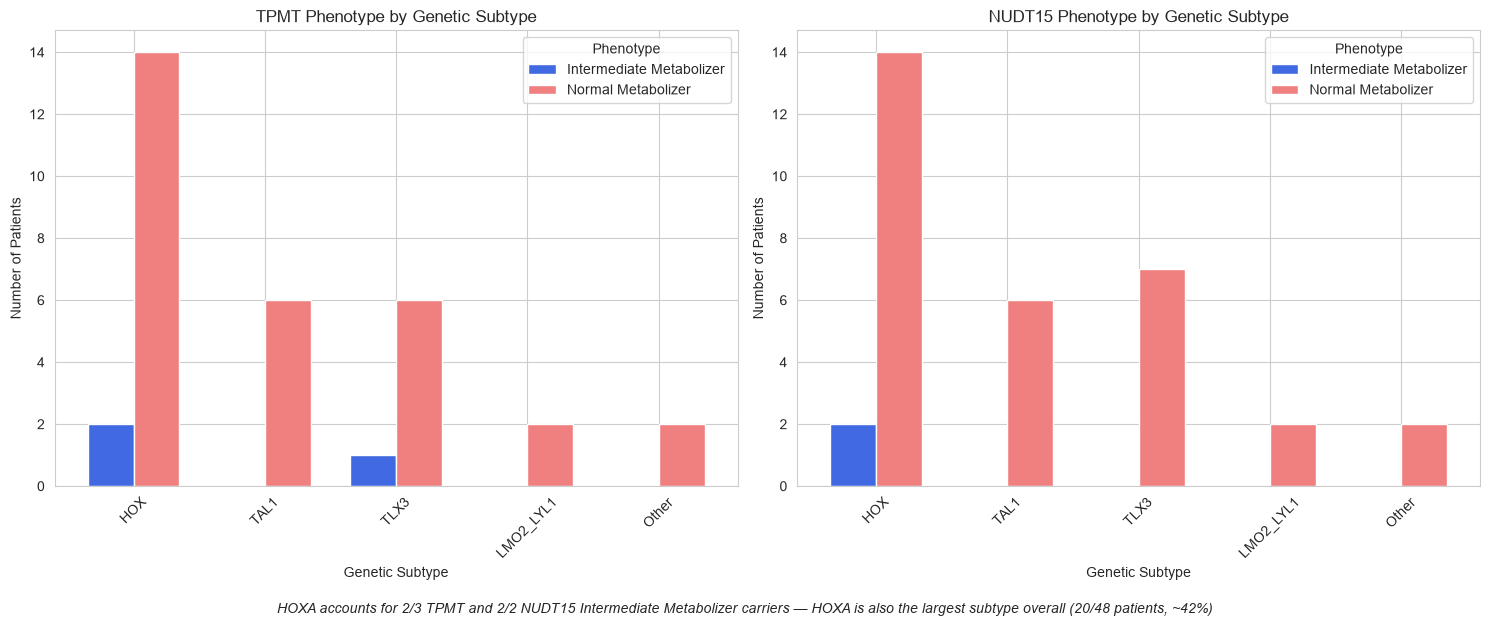

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
subtype_order = ['HOX', 'TAL1', 'TLX3', 'LMO2_LYL1', 'Other']

ct_tpmt_subtype = pd.crosstab(tpmt_subtype['final_group'], tpmt_subtype['phenotype']).reindex(subtype_order).fillna(0)
ct_tpmt_subtype.plot(kind='bar', ax=axes[0], color=['royalblue', 'lightcoral'], width=0.7)
axes[0].set_title('TPMT Phenotype by Genetic Subtype')
axes[0].set_xlabel('Genetic Subtype')
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Phenotype')

ct_nudt15_subtype = pd.crosstab(nudt15_subtype['final_group'], nudt15_subtype['phenotype']).reindex(subtype_order).fillna(0)
ct_nudt15_subtype.plot(kind='bar', ax=axes[1], color=['royalblue', 'lightcoral'], width=0.7)
axes[1].set_title('NUDT15 Phenotype by Genetic Subtype')
axes[1].set_xlabel('Genetic Subtype')
axes[1].set_ylabel('Number of Patients')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Phenotype')

plt.figtext(0.5, -0.03,
            'HOXA accounts for 2/3 TPMT and 2/2 NUDT15 Intermediate Metabolizer carriers — HOXA is also the largest subtype overall (20/48 patients, ~42%)',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('subtype_by_phenotype.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Base rate check: is HOXA overrepresented among variant carriers, or just the most common subtype overall?
print("Overall subtype distribution (T-ALL, all 33 patients):")
print(subtype_merged[subtype_merged['gene']=='TPMT']['final_group'].value_counts())
print("\nProportion HOXA overall:", (subtype_merged[subtype_merged['gene']=='TPMT']['final_group']=='HOX').mean())

Overall subtype distribution (T-ALL, all 33 patients):
final_group
HOX          16
TLX3          7
TAL1          6
Other         2
LMO2_LYL1     2
Name: count, dtype: int64

Proportion HOXA overall: 0.48484848484848486


### 6.5 BCP-ALL: genetic subtype vs phenotype (reliable calls)

In [24]:
bcp_subtype_df = pd.DataFrame({
    "patient_id": ["P0067","P0078","P0082","P0109","P0116","P0117","P0135","P0136","P0178","P0179","P0180","P0182","P0183"],
    "subtype_dx": ["TCF3-PBX","B-other","ETV6-RUNX1","B-other","TCF3-PBX","B-other","Hyperdiploid","B-other, DOWN","ETV6-RUNX1","Hypodiploid","ETV6-RUNX1","Hyperdiploid","Hyperdiploid"]
})

bcp_reliable = reliable[reliable['cohort'] == 'BCP-ALL']
bcp_merged = bcp_reliable.merge(bcp_subtype_df, on='patient_id', how='inner')

print("TPMT phenotype by subtype (BCP-ALL, reliable calls):")
print(pd.crosstab(bcp_merged[bcp_merged['gene']=='TPMT']['subtype_dx'], bcp_merged[bcp_merged['gene']=='TPMT']['phenotype']))

print("\nNUDT15 phenotype by subtype (BCP-ALL, reliable calls):")
print(pd.crosstab(bcp_merged[bcp_merged['gene']=='NUDT15']['subtype_dx'], bcp_merged[bcp_merged['gene']=='NUDT15']['phenotype']))

TPMT phenotype by subtype (BCP-ALL, reliable calls):
phenotype   Normal Metabolizer
subtype_dx                    
TCF3-PBX                     2

NUDT15 phenotype by subtype (BCP-ALL, reliable calls):
phenotype   Normal Metabolizer
subtype_dx                    
TCF3-PBX                     2


### 6.6 Blast % reduction as an outcome proxy (BCP-ALL)

In [25]:
bcpall_clinical['blast_pct_relapse_numeric'] = pd.to_numeric(bcpall_clinical['blast_pct_relapse'], errors='coerce')
bcpall_clinical['blast_pct_diagnosis_numeric'] = pd.to_numeric(bcpall_clinical['blast_pct_diagnosis'], errors='coerce')
bcpall_clinical['blast_reduction'] = bcpall_clinical['blast_pct_diagnosis_numeric'] - bcpall_clinical['blast_pct_relapse_numeric']

bcpall_full = df[df['cohort']=='BCP-ALL'].merge(bcpall_clinical, on='patient_id', how='left')
tpmt_bcp2 = bcpall_full[bcpall_full['gene']=='TPMT'][['patient_id','genotype','phenotype','confidence','blast_reduction']]
tpmt_bcp2.to_csv('~/Downloads/bcpall_blast_reduction.csv', index=False)

tpmt_bcp2.groupby('phenotype')['blast_reduction'].agg(['mean', 'std', 'count'])

,mean,std,count
phenotype,,,
Indeterminate,34.166667,23.785850,6
Normal Metabolizer,5.000000,4.242641,2


## 7. eQTL analysis (GTEx)

In [26]:
GTEX_API = "https://gtexportal.org/api/v2"

def get_gencode_id(gene_symbol):
    """Look up the versioned GENCODE ID for a gene symbol."""
    url = f"{GTEX_API}/reference/gene"
    params = {"geneId": gene_symbol}
    resp = requests.get(url, params=params)
    if resp.status_code == 200:
        data = resp.json()
        if data.get('data'):
            return data['data'][0]['gencodeId']
    print(f"Could not find gencodeId for {gene_symbol}: {resp.status_code} {resp.text[:200]}")
    return None

tpmt_gencode = get_gencode_id("TPMT")
time.sleep(0.5)
nudt15_gencode = get_gencode_id("NUDT15")

print("TPMT gencodeId:", tpmt_gencode)
print("NUDT15 gencodeId:", nudt15_gencode)

TPMT gencodeId: ENSG00000137364.4
NUDT15 gencodeId: ENSG00000136159.3


In [27]:
def get_gtex_eqtls(gencode_id, tissue="Whole_Blood"):
    """Query GTEx for significant eQTLs affecting a gene in a given tissue."""
    url = f"{GTEX_API}/association/singleTissueEqtl"
    params = {
        "gencodeId": gencode_id,
        "tissueSiteDetailId": tissue,
        "datasetId": "gtex_v8"
    }
    resp = requests.get(url, params=params)
    if resp.status_code == 200:
        return resp.json()
    else:
        print(f"Error {resp.status_code}: {resp.text[:300]}")
        return None

tpmt_eqtls = get_gtex_eqtls(tpmt_gencode)
time.sleep(0.5)
nudt15_eqtls = get_gtex_eqtls(nudt15_gencode)

tpmt_df = pd.DataFrame(tpmt_eqtls.get('data', [])) if tpmt_eqtls else pd.DataFrame()
nudt15_df = pd.DataFrame(nudt15_eqtls.get('data', [])) if nudt15_eqtls else pd.DataFrame()

print(f"TPMT significant eQTLs in Whole Blood: {len(tpmt_df)}")
print(f"NUDT15 significant eQTLs in Whole Blood: {len(nudt15_df)}")

TPMT significant eQTLs in Whole Blood: 220
NUDT15 significant eQTLs in Whole Blood: 0


In [28]:
print("=== Top 5 TPMT eQTLs by p-value ===")
print(tpmt_df.sort_values('pValue')[['snpId', 'pos', 'pValue', 'nes']].head())

print("\n=== Top 5 NUDT15 eQTLs by p-value ===")
print(nudt15_df.sort_values('pValue')[['snpId', 'pos', 'pValue', 'nes']].head() if len(nudt15_df) > 0 else "No eQTLs found")

=== Top 5 TPMT eQTLs by p-value ===
          snpId       pos        pValue       nes
111  rs13199975  18167848  8.966020e-46  0.380635
55    rs2518462  18145141  5.427330e-45  0.389170
68    rs2518469  18153099  5.691100e-45  0.397789
49    rs2518464  18142058  1.422710e-43  0.383715
60    rs4449636  18147788  1.717140e-43  0.383081

=== Top 5 NUDT15 eQTLs by p-value ===
No eQTLs found


In [29]:
# Our Sonic job used chr13:47,500,000-48,100,000 for the wide-region NUDT15 window
if len(nudt15_df) > 0:
    print("NUDT15 eQTL position range:", nudt15_df['pos'].min(), "-", nudt15_df['pos'].max())
    print("Our wide-region window: 47,500,000 - 48,100,000")

In [30]:
# nes = normalized effect size; negative means the alt allele decreases expression
top_tpmt_eqtls = tpmt_df.sort_values('pValue').head(5)
print(top_tpmt_eqtls[['snpId', 'pos', 'pValue', 'nes']])

          snpId       pos        pValue       nes
111  rs13199975  18167848  8.966020e-46  0.380635
55    rs2518462  18145141  5.427330e-45  0.389170
68    rs2518469  18153099  5.691100e-45  0.397789
49    rs2518464  18142058  1.422710e-43  0.383715
60    rs4449636  18147788  1.717140e-43  0.383081


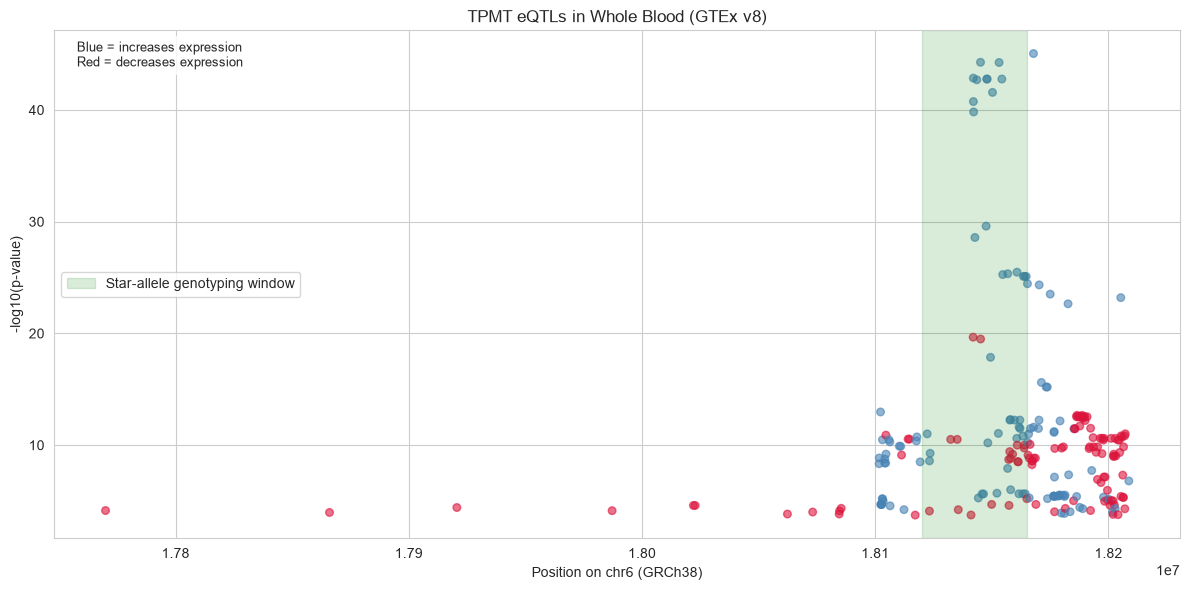

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))

tpmt_df['neg_log10_p'] = -np.log10(tpmt_df['pValue'])
colors = ['crimson' if x < 0 else 'steelblue' for x in tpmt_df['nes']]

ax.scatter(tpmt_df['pos'], tpmt_df['neg_log10_p'], c=colors, alpha=0.6, s=30)
ax.axvspan(18120000, 18165000, alpha=0.15, color='green', label='Star-allele genotyping window')

ax.set_xlabel('Position on chr6 (GRCh38)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('TPMT eQTLs in Whole Blood (GTEx v8)')
ax.legend()
ax.text(0.02, 0.98, 'Blue = increases expression\nRed = decreases expression',
        transform=ax.transAxes, verticalalignment='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('tpmt_eqtl_locus_plot.png', dpi=150, bbox_inches='tight')
plt.show()

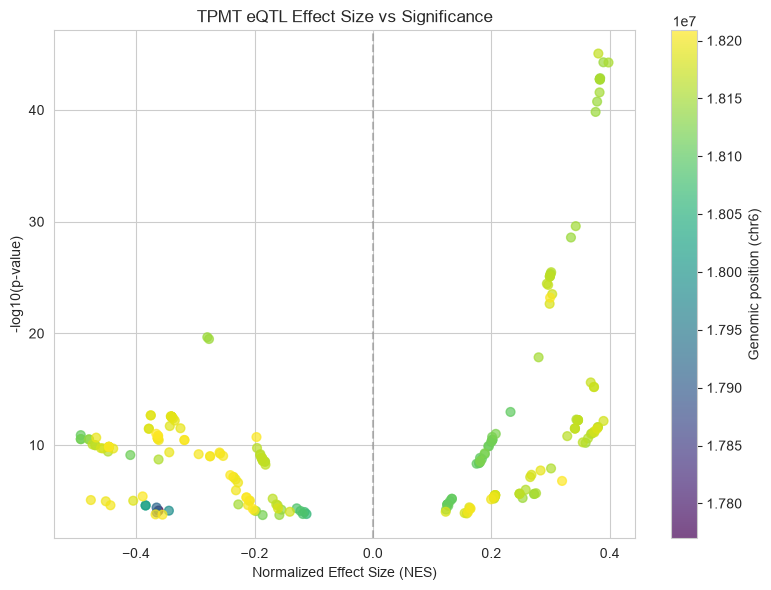

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(tpmt_df['nes'], tpmt_df['neg_log10_p'],
                      c=tpmt_df['pos'], cmap='viridis', alpha=0.7, s=40)

ax.set_xlabel('Normalized Effect Size (NES)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('TPMT eQTL Effect Size vs Significance')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Genomic position (chr6)')

plt.tight_layout()
plt.savefig('tpmt_eqtl_effect_vs_significance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. RNA-seq expression validation

In [33]:
# Load raw counts (messy header with full file paths) and normalize to CPM
counts_raw = pd.read_csv('~/Downloads/tpmt_nudt15_counts.tsv', sep='\t')
counts_raw.columns = [col.split('/')[-1].replace('.bam', '') if '.bam' in col else col for col in counts_raw.columns]

counts_long = counts_raw.melt(id_vars=['Geneid'],
                               value_vars=[c for c in counts_raw.columns if c.startswith('R')],
                               var_name='sample', value_name='raw_count')

gene_map = {'ENSG00000137364.5': 'TPMT', 'ENSG00000136159.4': 'NUDT15'}
counts_long['gene'] = counts_long['Geneid'].map(gene_map)

library_sizes = pd.read_csv('~/Downloads/library_sizes.tsv', sep='\t')
counts_long = counts_long.merge(library_sizes, on='sample', how='left')
counts_long['cpm'] = (counts_long['raw_count'] / counts_long['total_mapped_reads']) * 1e6

counts_long.to_csv('~/Downloads/rnaseq_tpmt_nudt15_normalized.csv', index=False)
print(f"Normalized {counts_long['sample'].nunique()} samples across {counts_long['gene'].nunique()} genes")

Normalized 31 samples across 2 genes


In [34]:
# Map R### sample IDs back to patient IDs and merge with genotype/phenotype calls
sample_to_patient = {
    "R058":"P011","R027":"P013","R048":"P016","R049":"P017","R028":"P018","R030":"P019",
    "R031":"P020","R033":"P022","R035":"P023","R038":"P024","R042":"P026","R044":"P028",
    "R045":"P029","R059":"P033","R063":"P037","R085":"P057","R088":"P058","R089":"P059",
    "R090":"P060","R092":"P061","R094":"P063","R095":"P064","R096":"P065","R097":"P066",
    "R098":"P080","R100":"P081","R102":"P082","R103":"P083","R104":"P084","R106":"P085",
    "R107":"P086"
}
counts_long['patient_id'] = counts_long['sample'].map(sample_to_patient)

expr_geno = counts_long.merge(
    df[['patient_id', 'gene', 'genotype', 'phenotype', 'confidence']],
    on=['patient_id', 'gene'], how='left'
)

tpmt_expr = expr_geno[expr_geno['gene'] == 'TPMT']
nudt15_expr = expr_geno[expr_geno['gene'] == 'NUDT15']

print("=== TPMT expression by phenotype ===")
print(tpmt_expr.groupby('phenotype')['cpm'].agg(['mean', 'std', 'count']))

print("\n=== NUDT15 expression by phenotype ===")
print(nudt15_expr.groupby('phenotype')['cpm'].agg(['mean', 'std', 'count']))

=== TPMT expression by phenotype ===
                        mean       std  count
phenotype                                    
Normal Metabolizer  3.152899  2.056179     23

=== NUDT15 expression by phenotype ===
                              mean       std  count
phenotype                                          
Intermediate Metabolizer  2.401414       NaN      1
Normal Metabolizer        3.758955  2.922797     22


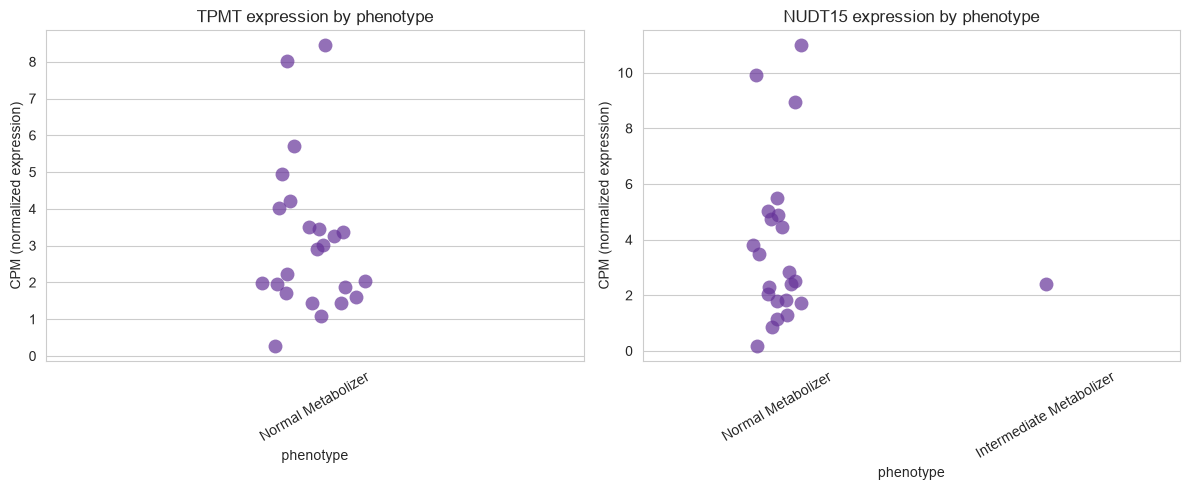

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, gene, gdf in zip(axes, ['TPMT', 'NUDT15'], [tpmt_expr, nudt15_expr]):
    sns.stripplot(data=gdf, x='phenotype', y='cpm', ax=ax, size=10, alpha=0.7, color="rebeccapurple")
    ax.set_title(f'{gene} expression by phenotype')
    ax.set_ylabel('CPM (normalized expression)')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('expression_by_genotype.png', dpi=150, bbox_inches='tight')
plt.show()

RNA-seq was available for 31/33 T-ALL patients. None of the TPMT variant carriers and only one of the two NUDT15 variant carriers had matched RNA-seq data, precluding a meaningful within-cohort genotype-expression comparison for TPMT. For NUDT15, the single available Intermediate Metaboliser sample showed expression within the range observed for Normal Metaboliser samples (n=1 vs n=22, not a statistical test).

## 9. Master analysis table

In [36]:
master = df.merge(
    tall_outcomes[['patient_id', 'outcome', 'final_group', 'ettp_status']],
    on='patient_id', how='left'
).merge(
    bcpall_clinical[['patient_id', 'remission_time_years', 'blast_pct_diagnosis']],
    on='patient_id', how='left'
)

master_clean = master[['patient_id', 'cohort', 'gene', 'genotype', 'phenotype', 'confidence',
                        'outcome', 'final_group', 'remission_time_years', 'blast_pct_diagnosis']]
master_clean.to_csv('~/Downloads/master_analysis_table.csv', index=False)
print(f"Saved master table: {len(master_clean)} rows, {master_clean['patient_id'].nunique()} patients")

Saved master table: 92 rows, 46 patients
